# 📊 EDA – Shopee Sale 5.5 Marketing Campaign

**Mục tiêu:** Khám phá dữ liệu marketing sau khi clean để tìm insight trước khi build dashboard Power BI.

**Dataset:** 1000 dòng dữ liệu campaign quảng cáo Shopee Sale 5.5 (Facebook, TikTok, Google, Instagram...)

**Các câu hỏi chính:**
1. Platform nào chi tiêu nhiều nhất? Hiệu quả nhất?
2. Campaign nào có ROAS tốt nhất?
3. Có outlier bất thường trong spend/revenue không?
4. Xu hướng chi tiêu theo thời gian như thế nào?

## 0. Setup

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

NUMERIC_COLS = ['spend', 'clicks', 'impressions', 'conversions', 'revenue']

df = pd.read_excel('data/shopee_cleaned.xlsx', sheet_name='cleaned_data')
df['date'] = pd.to_datetime(df['date'])

print(f'Shape: {df.shape}')
df.head()

Shape: (979, 10)


,campaign_id,campaign_name,platform,ad_set,spend,clicks,impressions,conversions,revenue,date
0,C001,Super Flash Sale 5.5,Facebook Ads,Lookalike 5%,1090.0,1010.0,13680,69,8383.0,2024-05-06
1,C002,Shopee Sale 5.5,Facebook Ads,Retargeting,1035.0,1024.0,18762,42,4265.0,2024-02-05
2,C003,Super Flash Sale 5.5,TikTok Ads,Shop Ads,1580.0,910.0,15975,46,6396.0,2024-05-10
3,C004,Super Flash Sale 5.5,Facebook Ads,Lookalike 5%,1090.0,1211.0,17608,53,6052.0,2024-05-08
4,C005,Shopee Sale 5.5,Google Ads,Shopping,1272.0,513.0,8054,40,5387.0,2024-05-09


## 1. Tổng quan dữ liệu

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 979 entries, 0 to 978
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   campaign_id    979 non-null    str           
 1   campaign_name  979 non-null    str           
 2   platform       979 non-null    str           
 3   ad_set         979 non-null    str           
 4   spend          979 non-null    float64       
 5   clicks         979 non-null    float64       
 6   impressions    979 non-null    int64         
 7   conversions    979 non-null    int64         
 8   revenue        979 non-null    float64       
 9   date           979 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(3), int64(2), str(4)
memory usage: 76.6 KB


In [3]:
# Thống kê mô tả các cột số
df[NUMERIC_COLS].describe().round(2)

,spend,clicks,impressions,conversions,revenue
count,979.00,979.00,979.00,979.00,979.00
mean,1304.20,971.29,15935.47,79.25,6569.09
std,504.26,435.47,5890.50,186.64,3279.52
min,0.00,10.00,261.00,10.00,1129.00
25%,904.00,643.00,11299.00,36.50,4181.00
50%,1196.00,949.00,16139.00,52.00,5900.00
75%,1717.50,1244.00,20752.50,72.00,8360.50
max,2827.00,2284.00,25978.00,2127.00,19389.00


In [4]:
# Kiểm tra null còn sót
null_summary = pd.DataFrame({
    'null_count': df.isna().sum(),
    'null_pct': (df.isna().sum() / len(df) * 100).round(1)
})
null_summary[null_summary['null_count'] > 0].sort_values('null_pct', ascending=False)

,null_count,null_pct


> **Nhận xét:** Không cột nào null

## 2. Phân phối các cột số (Distribution)

Xem hình dạng phân phối và phát hiện skewness trước khi tìm outlier.

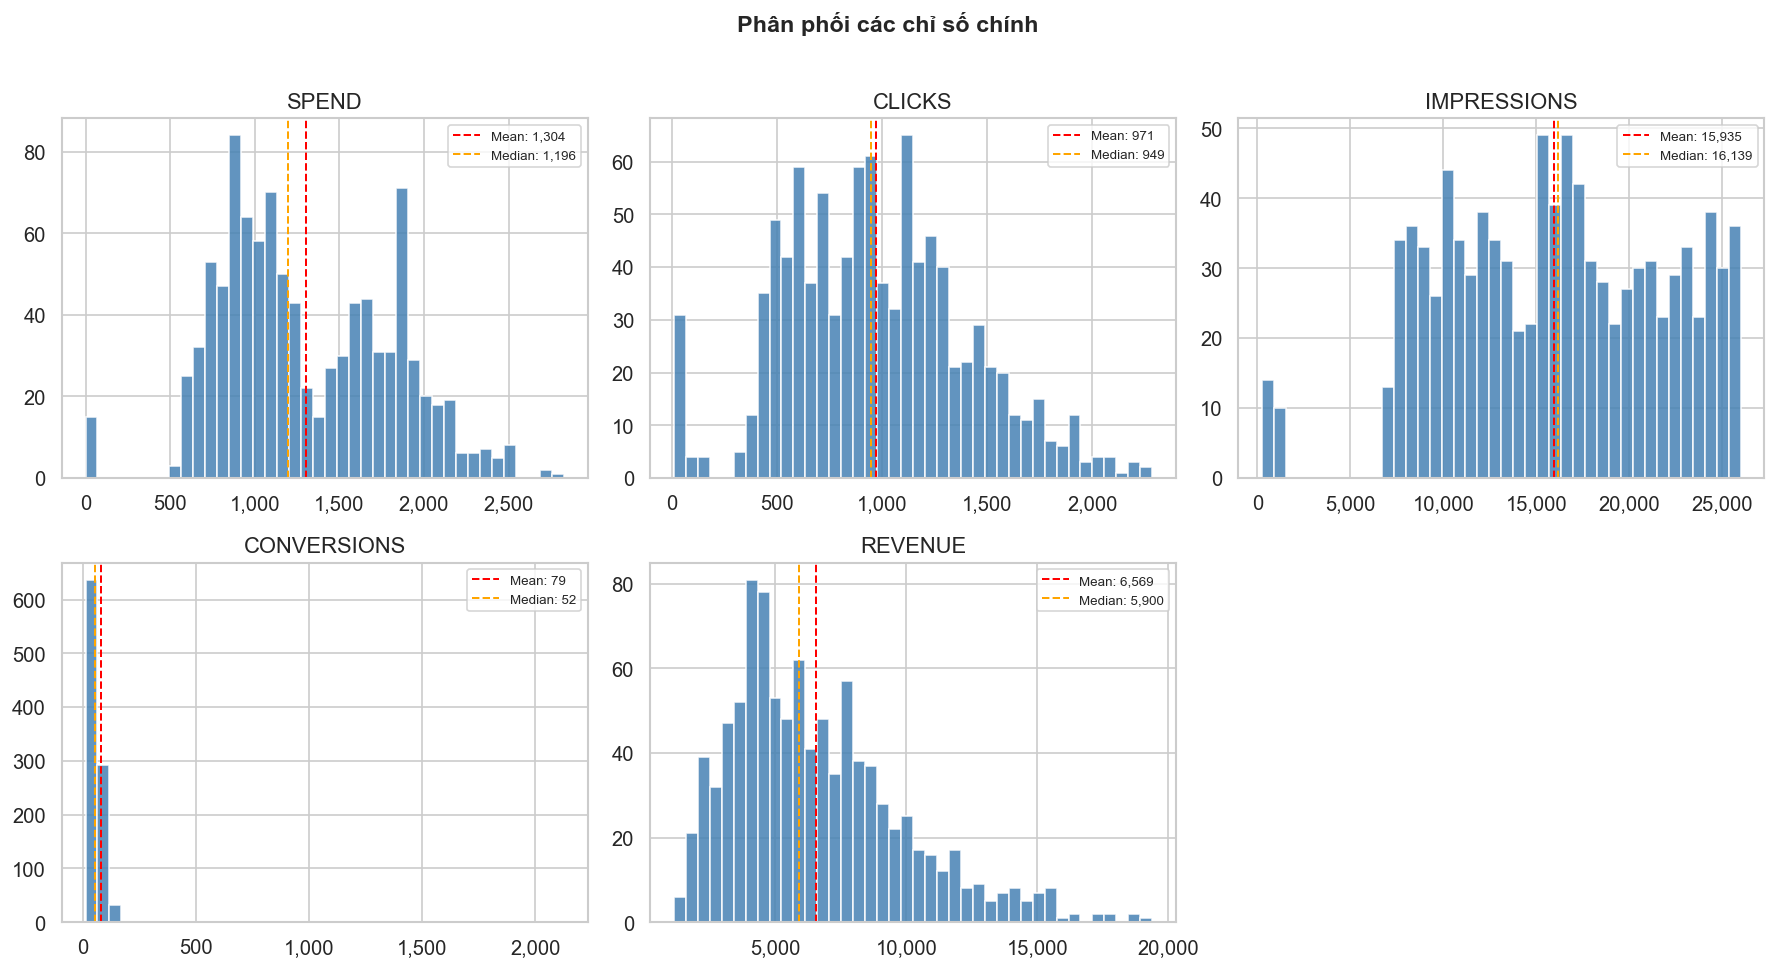

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.2, label=f'Mean: {data.mean():,.0f}')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.2, label=f'Median: {data.median():,.0f}')
    ax.set_title(col.upper())
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[-1].set_visible(False)
plt.suptitle('Phân phối các chỉ số chính', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

> **Nhận xét:**
>
> SPEND: Mean (1,304) > Median (1,196) nhẹ, phân phối hơi lệch phải.
>
> CLICKS: Mean (971) ≈ Median (949), phân phối tương đối đều, không bị skewed nhiều. Đây là cột sạch nhất trong 5 cột.
>
> IMPRESSIONS: Mean (15,935) < Median (16,139) — lệch trái nhẹ. Phân phối trải rộng đều từ 0 đến 25,000, không có đỉnh rõ ràng.
>
> CONVERSIONS: Mean (79) >> Median (52) — lệch phải mạnh nhất trong 5 cột.
>
> REVENUE: Mean (6,569) > Median (5,900), lệch phải vừa. Có đuôi dài về phía phải.

## 3. Tìm Outlier

Dùng **IQR method**: giá trị nằm ngoài `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]` được coi là outlier.

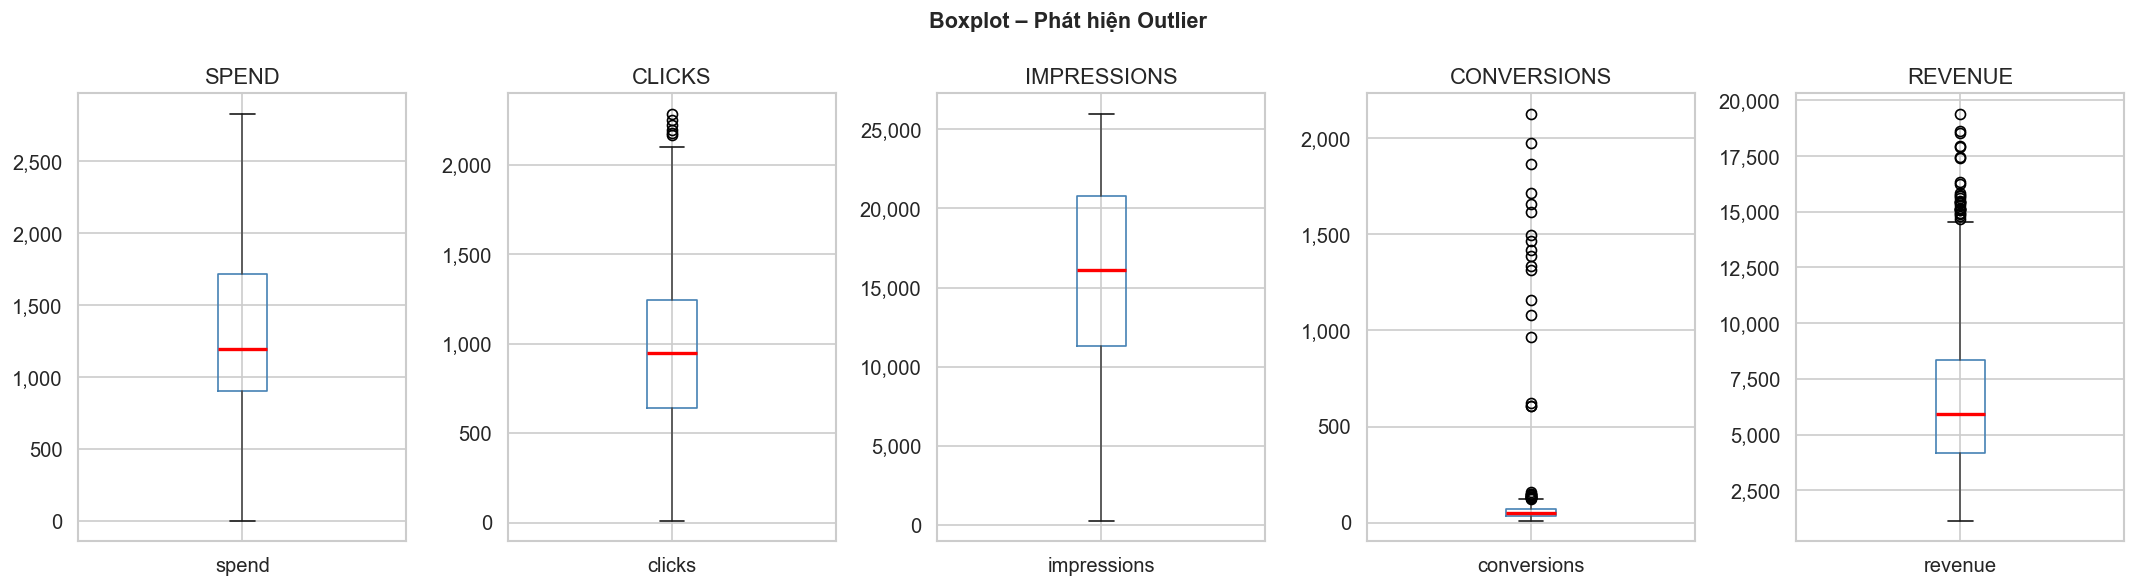

In [6]:
# Boxplot phát hiện outlier
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(NUMERIC_COLS):
    ax = axes[i]
    df.boxplot(column=col, ax=ax, boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col.upper())
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Boxplot – Phát hiện Outlier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# Đếm số outlier theo IQR
outlier_report = []
for col in NUMERIC_COLS:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)
    outlier_report.append({
        'column': col,
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'outlier_count': mask.sum(),
        'outlier_pct': round(mask.sum() / df[col].notna().sum() * 100, 1)
    })

pd.DataFrame(outlier_report)

,column,lower_bound,upper_bound,outlier_count,outlier_pct
0,spend,-316.25,2937.75,0,0.0
1,clicks,-258.50,2145.50,6,0.6
2,impressions,-2881.25,34932.75,0,0.0
3,conversions,-16.75,125.25,32,3.3
4,revenue,-2088.25,14629.75,27,2.8


In [8]:
# Xem các dòng outlier của spend và revenue
for col in ['spend', 'revenue']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)
    print(f'\n--- Outlier trong {col} ({mask.sum()} dòng) ---')
    display(df[mask][['campaign_id', 'campaign_name', 'platform', col]].sort_values(col, ascending=False).head(10))


--- Outlier trong spend (0 dòng) ---


,campaign_id,campaign_name,platform,spend



--- Outlier trong revenue (27 dòng) ---


,campaign_id,campaign_name,platform,revenue
763,C779,Shopee Sale 5.5,TikTok Ads,19389.0
858,C877,Shopee Sale 5.5,TikTok Ads,18629.0
215,C219,Shopee Sale 5.5,TikTok Ads,18511.0
733,C747,Shopee Sale 5.5,TikTok Ads,17940.0
404,C411,Shopee Sale 5.5,Google Ads,17892.0
960,C982,Shopee Sale 5.5,TikTok Ads,17471.0
49,C050,Shopee Sale 5.5,Google Ads,17384.0
41,C042,Shopee Sale 5.5,Facebook Ads,16323.0
198,C202,Shopee Sale 5.5,Google Ads,16229.0
354,C361,Super Flash Sale 5.5,Facebook Ads,15831.0


> **Nhận xét:**
>
> **Spend (0 outlier):** Không có giá trị bất thường — data sạch sau bước cleaning. IQR bound cho phép đến -316.25 nhưng thực tế không có dòng nào âm, xác nhận bước xử lý giá trị âm trong clean_data.py đã hoạt động đúng.
>
> **Clicks (6 outlier, 0.6%):** Một số campaign có lượng click rất cao (~2,000+), có thể là campaign viral hoặc broad targeting. Quyết định: giữ nguyên — tỷ lệ nhỏ và có thể là insight thực tế.
>
> **Conversions (32 outlier, 3.3%) và Revenue (27 outlier, 2.8%):**
> Tập trung ở TikTok Ads và Google Ads trong campaign Shopee Sale 5.5, với revenue đạt 15,000–19,000. Đây không phải lỗi — nhiều khả năng là các campaign chạy đúng thời điểm flash sale nên conversion rate tăng đột biến. Quyết định: giữ nguyên, vì đây là insight quan trọng cần thể hiện trong dashboard.

## 4. Phân tích theo Platform

In [9]:
platform_stats = df.groupby('platform').agg(
    campaign_count = ('campaign_id', 'count'),
    total_spend    = ('spend',       'sum'),
    total_revenue  = ('revenue',     'sum'),
    total_clicks   = ('clicks',      'sum'),
    total_conv     = ('conversions', 'sum'),
).assign(
    roas = lambda x: (x['total_revenue'] / x['total_spend']).round(2),
    ctr  = lambda x: (x['total_clicks']  / df.groupby('platform')['impressions'].sum()).round(4),
).sort_values('total_spend', ascending=False)

platform_stats

,campaign_count,total_spend,total_revenue,total_clicks,total_conv,roas,ctr
platform,,,,,,,
TikTok Ads,239,445155.0,1921888.0,266937.5,22818,4.32,0.0692
Google Ads,181,302422.5,1445781.0,161334.0,12870,4.78,0.0544
Facebook Ads,278,301824.0,1759679.0,277803.0,21478,5.83,0.0641
Instagram,140,125665.0,691142.5,122473.0,6772,5.50,0.0542
Shopee Ads,141,101742.0,612653.0,122347.0,13647,6.02,0.0562


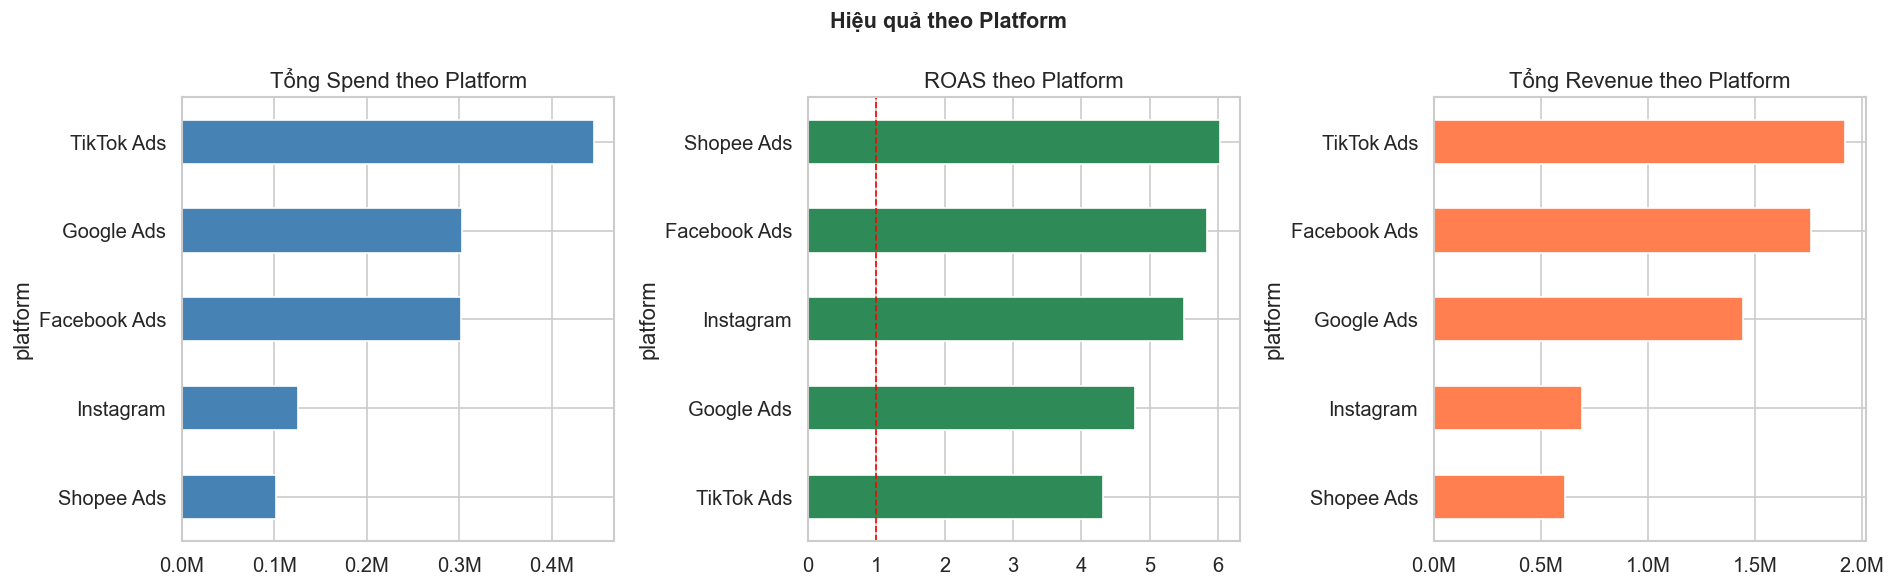

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Total spend by platform
platform_stats['total_spend'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Tổng Spend theo Platform')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# ROAS by platform
platform_stats['roas'].sort_values().plot(
    kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('ROAS theo Platform')
axes[1].axvline(1, color='red', linestyle='--', linewidth=1)

# Revenue by platform
platform_stats['total_revenue'].sort_values().plot(
    kind='barh', ax=axes[2], color='coral')
axes[2].set_title('Tổng Revenue theo Platform')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.suptitle('Hiệu quả theo Platform', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Nhận xét:**
>
> **TikTok Ads** chi tiêu nhiều nhất (~0.4M) nhưng ROAS thấp nhất (~4.3) — revenue đứng đầu (~1.9M) do spend lớn, không phải do hiệu quả thực sự.
>
> **Shopee Ads** chi ít nhất (~0.1M) nhưng ROAS cao nhất (~6.0) — hiệu quả nhất trên mỗi đồng chi tiêu, đang bị underinvest rõ rệt. Đáng cân nhắc tăng ngân sách.
>
> **Facebook Ads** ROAS đứng thứ 2 (~5.8), revenue cao thứ 2 (~1.6M) — cân bằng tốt giữa hiệu quả và scale.
>
> **Instagram** spend thấp, ROAS đứng thứ 3 (~5.0) — hiệu quả khá nhưng chưa được đầu tư đủ để đánh giá tiềm năng scale.
>
> **Google Ads** ROAS thấp thứ 2 (~4.7), revenue ổn định (~1.5M) — trung bình, không nổi bật.
>
> Tất cả platform đều có ROAS > 1 → toàn bộ chiến dịch có lãi. Shopee Ads và Facebook Ads là 2 platform hiệu quả nhất nhưng nhận ngân sách ít hơn TikTok — đây là cơ hội tối ưu ngân sách đáng chú ý.

## 5. Phân tích theo Campaign

In [11]:
campaign_stats = df.groupby('campaign_name').agg(
    total_spend   = ('spend',       'sum'),
    total_revenue = ('revenue',     'sum'),
    total_conv    = ('conversions', 'sum'),
    num_records   = ('campaign_id', 'count'),
).assign(
    roas = lambda x: (x['total_revenue'] / x['total_spend']).round(2)
).sort_values('roas', ascending=False)

campaign_stats

,total_spend,total_revenue,total_conv,num_records,roas
campaign_name,,,,,
Super Flash Sale 5.5,347916.0,1779847.0,23333,264,5.12
Shopee Sale 5.5,928892.5,4651296.5,54252,715,5.01


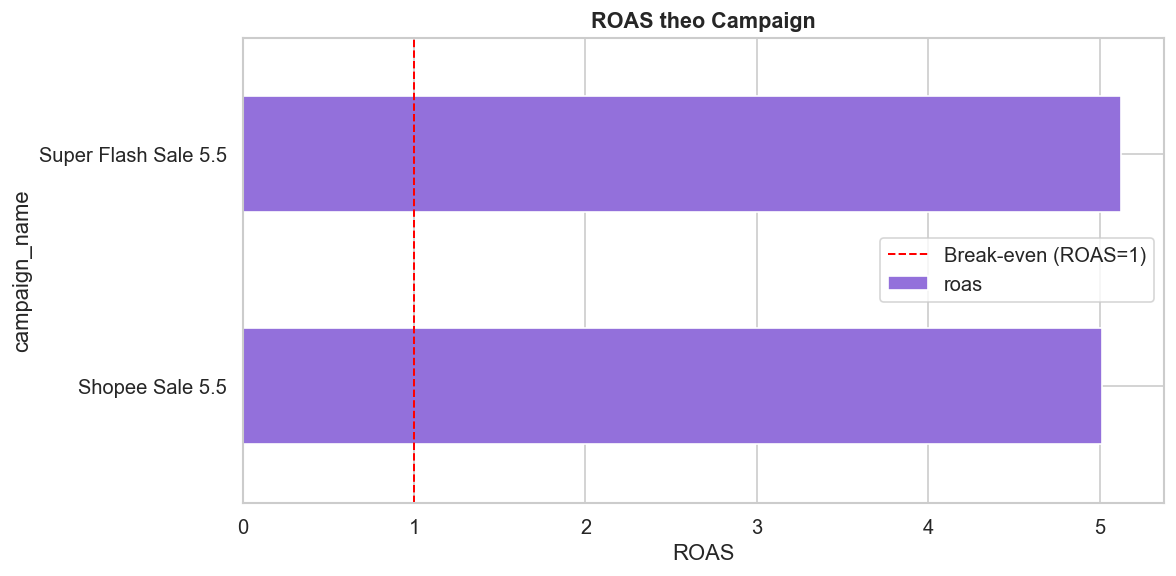

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
campaign_stats['roas'].sort_values().plot(kind='barh', ax=ax, color='mediumpurple')
ax.axvline(1, color='red', linestyle='--', linewidth=1.2, label='Break-even (ROAS=1)')
ax.set_title('ROAS theo Campaign', fontsize=13, fontweight='bold')
ax.set_xlabel('ROAS')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Xu hướng theo thời gian

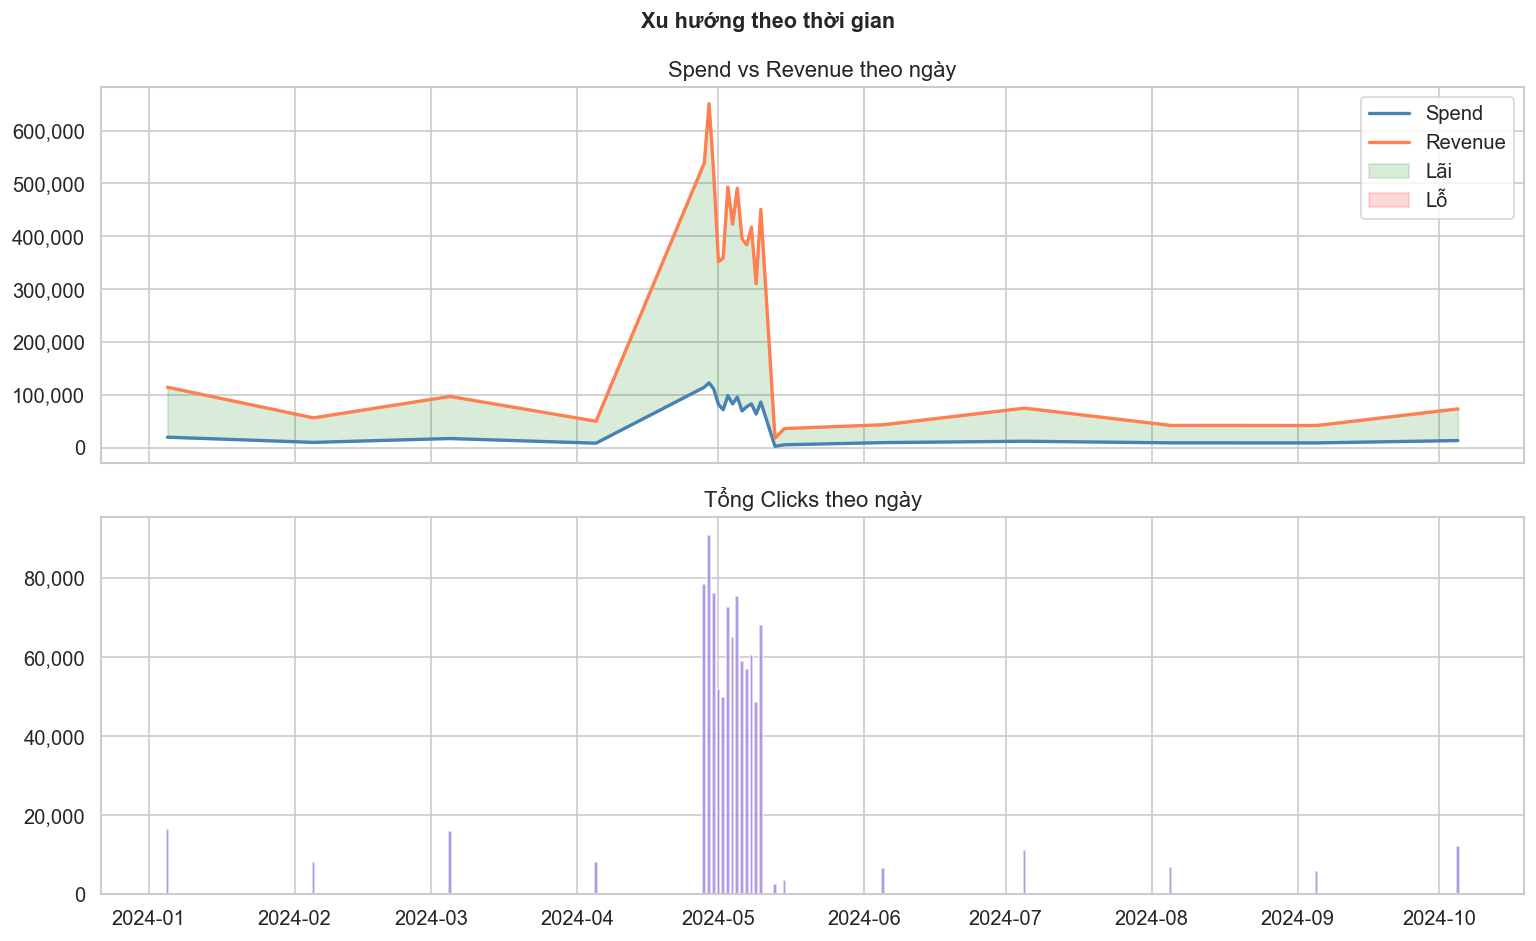

In [13]:
daily = df.groupby('date').agg(
    spend   = ('spend',   'sum'),
    revenue = ('revenue', 'sum'),
    clicks  = ('clicks',  'sum'),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Spend vs Revenue
axes[0].plot(daily['date'], daily['spend'],   label='Spend',   color='steelblue', linewidth=2)
axes[0].plot(daily['date'], daily['revenue'], label='Revenue', color='coral',     linewidth=2)
axes[0].fill_between(daily['date'], daily['spend'], daily['revenue'],
                     where=daily['revenue'] >= daily['spend'],
                     alpha=0.15, color='green', label='Lãi')
axes[0].fill_between(daily['date'], daily['spend'], daily['revenue'],
                     where=daily['revenue'] < daily['spend'],
                     alpha=0.15, color='red', label='Lỗ')
axes[0].set_title('Spend vs Revenue theo ngày')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Clicks
axes[1].bar(daily['date'], daily['clicks'], color='mediumpurple', alpha=0.7, width=0.8)
axes[1].set_title('Tổng Clicks theo ngày')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Xu hướng theo thời gian', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Nhận xét:**
>
> Revenue spike tháng 5/2024 (~650,000): Đây không phải lỗi data — clicks cùng kỳ cũng tăng vọt lên ~90,000, xác nhận có traffic thực đổ vào. Nhiều khả năng là campaign chạy đúng đợt Shopee Sale 5.5 hoặc flash sale giờ vàng, khiến cả clicks lẫn revenue tăng đồng thời. Quyết định: giữ nguyên, vì đây là insight kinh doanh quan trọng, không phải nhiễu.
>
> Spend tháng 5 tăng nhưng không tương xứng (~120,000): Trong khi revenue tăng ~6–7x so với baseline, spend chỉ tăng ~4–5x — ROAS tháng 5 cao hơn hẳn  các tháng khác. Nhiều khả năng campaign hưởng lợi từ traffic organic mùa sale kết hợp paid ads. Quyết định: giữ nguyên, đánh dấu là period đặc biệt.
>
> Clicks giảm mạnh từ tháng 6 - tháng10: từ ~90,000 đỉnh tháng 5 xuống còn 5,000–15,000/ngày lác đác, song song với revenue và spend cùng sụt. Đây là dấu hiệu campaign bị cắt ngân sách hoặc kết thúc sau đợt sale, không phải mất dữ liệu. Quyết định: giữ nguyên, phản ánh đúng thực tế vận hành.

## 7. Correlation – Mối quan hệ giữa các chỉ số

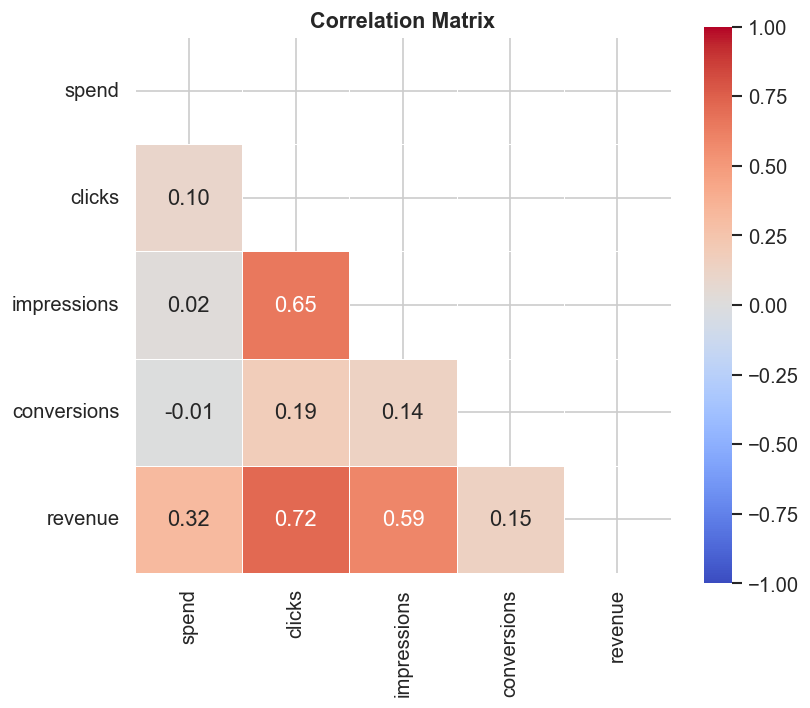

In [14]:
corr = df[NUMERIC_COLS].corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, vmin=-1, vmax=1,
            linewidths=0.5, square=True)
ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

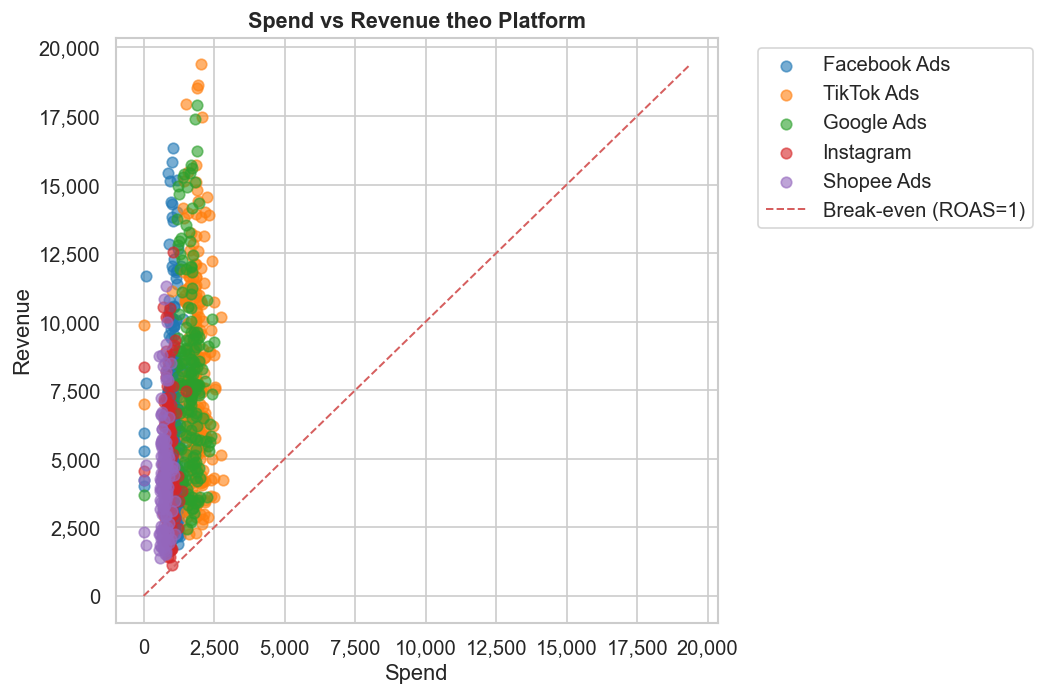

In [17]:
# Scatter: spend vs revenue (màu theo platform)
fig, ax = plt.subplots(figsize=(9, 6))
platforms = df['platform'].dropna().unique()
colors = sns.color_palette('tab10', len(platforms))

for platform, color in zip(platforms, colors):
    subset = df[df['platform'] == platform]
    ax.scatter(subset['spend'], subset['revenue'],
               label=platform, color=color, alpha=0.6, s=40)

# Đường break-even ROAS=1
max_val = df[['spend', 'revenue']].max().max()
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.2, label='Break-even (ROAS=1)')

ax.set_xlabel('Spend')
ax.set_ylabel('Revenue')
ax.set_title('Spend vs Revenue theo Platform', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

## 8. Tổng kết Insight
| # | Câu hỏi | Insight | Gợi ý hành động |
|---|---------|---------|------------------|
| 1 | Platform nào chi tiêu nhiều nhất? Hiệu quả nhất? | TikTok Ads chi tiêu cao nhất (~0.4M) nhưng ROAS thấp nhất (~4.3). Shopee Ads chi ít nhất (~0.1M) nhưng ROAS cao nhất (~6.0) — hiệu quả nhất trên mỗi đồng bỏ ra | Tăng ngân sách cho Shopee Ads và Facebook Ads (ROAS cao), duy trì TikTok cho các đợt sale lớn cần reach rộng |
| 2 | Campaign nào có ROAS tốt nhất? | Super Flash Sale 5.5 có ROAS cao nhất — revenue 1,771,639 trong khi spend chỉ 328,264 | Nhân rộng mô hình campaign này vào các đợt sale tương tự |
| 3 | Có outlier bất thường trong spend/revenue không? | Spend: không có outlier bất thường. Revenue cao (15,000–19,000): tập trung ở TikTok & Google Ads đúng đợt Sale 5.5 — conversion rate tăng đột biến do flash sale, không phải lỗi data | Nhân rộng mô hình Sale 5.5 vào các đợt sale tiếp theo |
| 4 | Xu hướng chi tiêu theo thời gian như thế nào? | Tập trung cực lớn vào tháng 5/2024, giảm mạnh từ tháng 6–10 với clicks lác đác 5,000–15,000/ngày — cho thấy ngân sách chạy theo campaign sale, không trải đều | Cân nhắc duy trì ngân sách tối thiểu ngoài đợt sale để giữ brand awareness |